<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W03_%5BMLP_Emotion_Classification_by_Images%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
! gdown --id 1GaTMURqIQTjtalbNVAyVgPIEis21A0r8
! unzip /content/FER-2013.zip

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1GaTMURqIQTjtalbNVAyVgPIEis21A0r8
From (redirected): https://drive.google.com/uc?id=1GaTMURqIQTjtalbNVAyVgPIEis21A0r8&confirm=t&uuid=2f7a77b7-56fd-467a-bb19-b18bc65092de
To: /content/FER-2013.zip
100% 63.3M/63.3M [00:00<00:00, 100MB/s]
Archive:  /content/FER-2013.zip
replace test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [32]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize
from torchvision.io import read_image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
# Device settings
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
  torch.cuda.manual_seed(random_state)


In [34]:
train_dir = "/content/train"
test_dir = "/content/test"

classes = os.listdir(train_dir)
print(classes)
label2idx = {cls:idx for idx, cls in enumerate(classes)}
print(label2idx["happy"])
idx2label = {idx:cls for idx, cls in enumerate(classes)}
print(idx2label)



['surprise', 'sad', 'fear', 'neutral', 'angry', 'happy', 'disgust']
5
{0: 'surprise', 1: 'sad', 2: 'fear', 3: 'neutral', 4: 'angry', 5: 'happy', 6: 'disgust'}


In [35]:
from pickle import TRUE
# DataLoader
class ImageDataset(Dataset):
  def __init__(self, img_dir, label2idx, img_size, norm=True, split="train", train_ratio=0.8):

    self.resize = Resize((img_height, img_width))
    self.norm = norm
    self.split = split
    self.train_ratio = train_ratio
    self.img_dir = img_dir
    self.label2idx = label2idx
    self.img_paths , self.img_labels = self.read_image_file()

    if split in ["train", "val"] and "train" in img_dir.lower():
      train_data, val_data = train_test_split(list(zip(self.img_paths, self.img_labels)),
                                              train_size = self.train_ratio,
                                              random_state=random_state,
                                              stratify=self.img_labels #Use for the imbalanced labels. Make the train and test set have the full kind of labels.Use stratify when you want balanced class distributions in your splits.
                                              )
      if split == "train":
        self.img_paths, self.img_labels = zip(*train_data)
      if split == "val":
        self.img_paths, self.img_labels = zip(*val_data)


  def read_image_file(self):
    img_paths = []
    img_labels = []
    for cls in self.label2idx.keys():
      for img in os.listdir(os.path.join(self.img_dir, cls)):
        img_paths.append(os.path.join(self.img_dir, cls, img))
        img_labels.append(cls)

    return img_paths, img_labels

  def __len__(self):
    return len(self.img_paths)

  def __getitem__(self, index):
    img_path = self.img_paths[index]
    cls = self.img_labels[index]

    # Normalize image
    img = self.resize(read_image(img_path))
    img = img.type(torch.float32)

    if self.norm:
      img = (img/127.5) - 1

    return img, self.label2idx[cls]

batch_size = 256
img_height = 128
img_width = 128

train_dataset = ImageDataset(train_dir, label2idx, img_size=(img_height, img_width), norm=True, split="train")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = ImageDataset(train_dir, label2idx, img_size=(img_height, img_width), norm=True, split="val")
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = ImageDataset(test_dir, label2idx, img_size=(img_height, img_width), norm=True, split="test")
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

img, idxLabel = train_dataset.__getitem__(4)
print(img, idxLabel)


tensor([[[-0.4745, -0.4824, -0.5059,  ..., -0.5608, -0.5765, -0.5765],
         [-0.4745, -0.4824, -0.5137,  ..., -0.5608, -0.5765, -0.5765],
         [-0.4824, -0.4902, -0.5216,  ..., -0.5765, -0.5765, -0.5765],
         ...,
         [-0.2392, -0.2392, -0.2549,  ..., -0.3569, -0.3255, -0.3176],
         [-0.2157, -0.2235, -0.2392,  ..., -0.3569, -0.3255, -0.3255],
         [-0.2157, -0.2157, -0.2392,  ..., -0.3569, -0.3333, -0.3255]]]) 5


tensor(5)


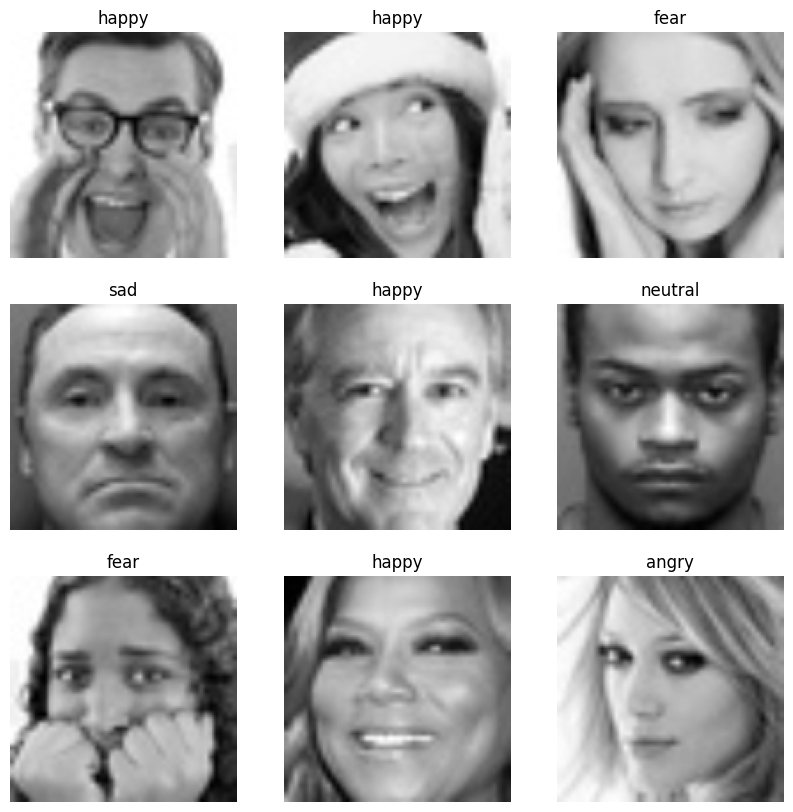

In [36]:
image_batch, label_batch = next(iter(train_loader))
print(label_batch[1])
plt.figure(figsize=(10, 10))
# Print 9 image with labels
for i in range(9):
  ax = plt. subplot (3, 3, i + 1)
  minv = image_batch [i]. numpy (). min ()
  maxv = image_batch [i]. numpy (). max ()
  plt . imshow (np. squeeze ( image_batch [i]. numpy ()), vmin =minv , vmax =maxv, cmap ="gray")
  label = label_batch[i]
  plt.title (idx2label[label.item()])
  plt.axis("off")


In [37]:
# Construct Multi-Layer Perceptron Network
class MLP(nn.Module):
  def __init__(self, input_dims, hidden_dims, output_dims):
    super(MLP, self).__init__()
    self.linear1 = nn.Linear(input_dims, hidden_dims*4)
    self.linear2 = nn.Linear(hidden_dims*4, hidden_dims*2)
    self.linear3 = nn.Linear(hidden_dims*2, hidden_dims)
    self.output = nn.Linear(hidden_dims, output_dims)

  def forward(self, x):
    x = nn.Flatten()(x)
    x = self.linear1(x)
    x = F.relu(x)
    x = self.linear2(x)
    x = F.relu(x)
    x = self.linear3(x)
    x = F.relu(x)
    out = self.output(x)
    return out.squeeze(1)

input_dims = img_height * img_width
hidden_dims = 64
output_dims = len(classes)
lr = 0.01

MLP_model = MLP(input_dims=input_dims, hidden_dims=hidden_dims, output_dims=output_dims)
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(MLP_model.parameters(), lr=lr)


In [38]:
# Construct Accuracy function
def accuracy(y_hat, y):
  _, y_hat = torch.max(y_hat, dim = 1)
  correct = (y_hat == y).sum().item()
  accuracy = correct / len(y)
  return accuracy

In [39]:
epochs = 40
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):

  # Training part
  train_loss = 0.0
  train_predict = []
  train_target = []
  MLP_model.train()
  for X_samples, y_samples in (train_loader):
    X_samples = X_samples.to(device)
    y_samples = y_samples.to(device)
    optimizer.zero_grad()
    output = MLP_model(X_samples)
    loss = criterion(output, y_samples)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

    train_predict.append(output.detach().cpu())
    train_target.append(y_samples.cpu())

  train_loss /= len(train_loader)
  train_losses.append(train_loss)

  train_predict = torch.cat(train_predict)
  train_target = torch.cat(train_target)
  train_acc = accuracy(train_predict, train_target)
  train_accs.append(train_acc)

  # Evaluation part
  val_loss = 0.0
  val_predict = []
  val_target = []
  MLP_model.eval()
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)
      outputs = MLP_model(X_samples)
      loss = criterion(outputs, y_samples)
      val_loss += loss.item()

      val_predict.append(outputs.cpu())
      val_target.append(y_samples.cpu())
  val_loss /= len(val_loader)
  val_losses.append(val_loss)

  val_predict = torch.cat(val_predict)
  val_target = torch.cat(val_target)
  val_acc = accuracy(val_predict, val_target)
  val_accs.append(val_acc)
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')


\ nEPOCH 1:\ tTraining loss : 1.907	Validation loss : 1.868
\ nEPOCH 2:\ tTraining loss : 1.837	Validation loss : 1.820
\ nEPOCH 3:\ tTraining loss : 1.804	Validation loss : 1.799
\ nEPOCH 4:\ tTraining loss : 1.785	Validation loss : 1.783
\ nEPOCH 5:\ tTraining loss : 1.770	Validation loss : 1.768
\ nEPOCH 6:\ tTraining loss : 1.753	Validation loss : 1.751
\ nEPOCH 7:\ tTraining loss : 1.734	Validation loss : 1.731
\ nEPOCH 8:\ tTraining loss : 1.713	Validation loss : 1.710
\ nEPOCH 9:\ tTraining loss : 1.692	Validation loss : 1.690
\ nEPOCH 10:\ tTraining loss : 1.672	Validation loss : 1.671
\ nEPOCH 11:\ tTraining loss : 1.655	Validation loss : 1.657
\ nEPOCH 12:\ tTraining loss : 1.641	Validation loss : 1.648
\ nEPOCH 13:\ tTraining loss : 1.631	Validation loss : 1.638
\ nEPOCH 14:\ tTraining loss : 1.620	Validation loss : 1.631
\ nEPOCH 15:\ tTraining loss : 1.611	Validation loss : 1.625
\ nEPOCH 16:\ tTraining loss : 1.602	Validation loss : 1.619
\ nEPOCH 17:\ tTraining loss : 1.

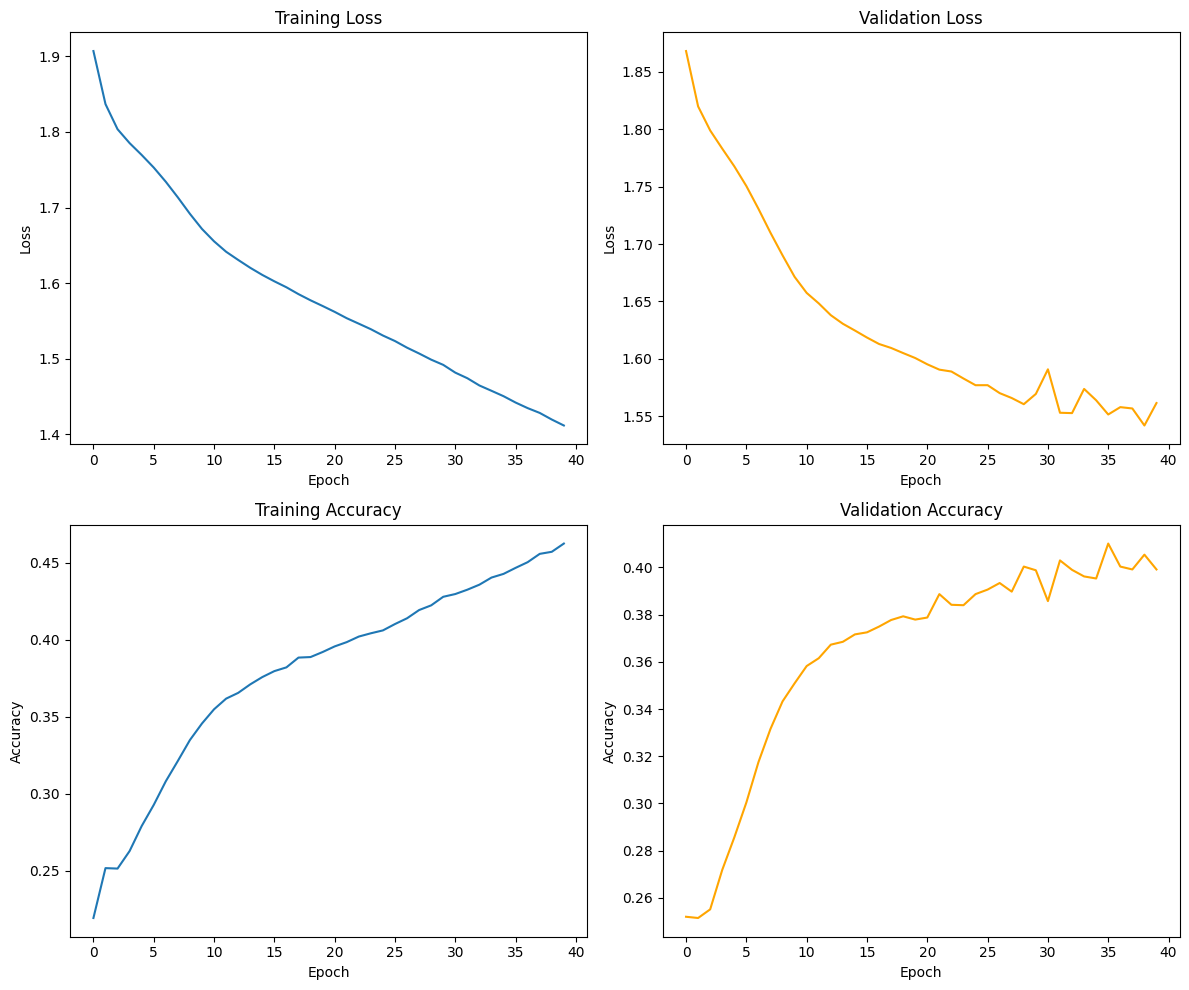

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

In [42]:
test_target = []
test_predict = []
MLP_model.eval()

with torch.no_grad():
    for X_samples, y_samples in test_loader:
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)

        outputs = MLP_model(X_samples)

        test_predict.append(outputs.cpu())
        test_target.append(y_samples.cpu())

test_predict = torch.cat(test_predict)
test_target = torch.cat(test_target)

val_acc = accuracy(test_predict, test_target)

print('Evaluation on test set:')
print(f'Accuracy: {val_acc}')


Evaluation on test set:
Accuracy: 0.40192254109779885
